<a href="https://colab.research.google.com/github/agatastachowiak/clinical-data-sql-analysis/blob/main/notebooks/P2_sql_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# PhysioNet's standard recursive download command for open-access projects
!wget -r -N -c -np https://physionet.org/files/mimiciii-demo/1.4/

--2026-09-14 14:57:32--  https://physionet.org/files/mimiciii-demo/1.4/
Resolving physionet.org (physionet.org)... 18.25.8.254
Connecting to physionet.org (physionet.org)|18.25.8.254|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘physionet.org/files/mimiciii-demo/1.4/index.html’

physionet.org/files     [ <=>                ]   3.50K  --.-KB/s    in 0s      

Last-modified header missing -- time-stamps turned off.
2026-09-14 14:57:32 (436 MB/s) - ‘physionet.org/files/mimiciii-demo/1.4/index.html’ saved [3588]

Loading robots.txt; please ignore errors.
--2026-09-14 14:57:32--  https://physionet.org/robots.txt
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 22 [text/plain]
Saving to: ‘physionet.org/robots.txt’

physionet.org/robot 100%[===================>]      22  --.-KB/s    in 0s      

2026-09-14 14:57:32 (6.80 MB/s) - ‘physionet.org/robots.txt’ saved [22/22]

--20

In [3]:
import os
for f in sorted(os.listdir('physionet.org/files/mimiciii-demo/1.4/')):
    print(f)

ADMISSIONS.csv
CALLOUT.csv
CAREGIVERS.csv
CHARTEVENTS.csv
CPTEVENTS.csv
DATETIMEEVENTS.csv
DIAGNOSES_ICD.csv
DRGCODES.csv
D_CPT.csv
D_ICD_DIAGNOSES.csv
D_ICD_PROCEDURES.csv
D_ITEMS.csv
D_LABITEMS.csv
ICUSTAYS.csv
INPUTEVENTS_CV.csv
INPUTEVENTS_MV.csv
LABEVENTS.csv
LICENSE.txt
MICROBIOLOGYEVENTS.csv
NOTEEVENTS.csv
OUTPUTEVENTS.csv
PATIENTS.csv
PRESCRIPTIONS.csv
PROCEDUREEVENTS_MV.csv
PROCEDURES_ICD.csv
SERVICES.csv
SHA256SUMS.txt
TRANSFERS.csv
index.html


In [4]:
'''
Load every CSV into a single SQLite database file. This turns the folder of
CSVs into one real, queryable relational database, which is what lets me write
genuine SQL (joins across tables, etc.) instead of just reading files individually.
'''
import sqlite3 #a lightweight, file-based database engine
import pandas as pd
import os

data_dir = 'physionet.org/files/mimiciii-demo/1.4/'
db_path = 'mimic_demo.db'

conn = sqlite3.connect(db_path) #creates a SQLite database file

csv_files = [f for f in os.listdir(data_dir) if f.endswith('.csv')]

# reads each CSV with pandas, then .to_sql(...) writes it in as a proper database table
for csv_file in csv_files:
    table_name = csv_file.replace('.csv', '').lower()
    df = pd.read_csv(os.path.join(data_dir, csv_file), low_memory=False)
    df.to_sql(table_name, conn, if_exists='replace', index=False)
    print(f"Loaded {table_name}: {df.shape[0]} rows, {df.shape[1]} columns")

conn.close()
print("\nDatabase built:", db_path)

Loaded labevents: 76074 rows, 9 columns
Loaded d_labitems: 753 rows, 6 columns
Loaded drgcodes: 297 rows, 8 columns
Loaded prescriptions: 10398 rows, 19 columns
Loaded services: 163 rows, 6 columns
Loaded d_cpt: 134 rows, 9 columns
Loaded cptevents: 1579 rows, 12 columns
Loaded datetimeevents: 15551 rows, 14 columns
Loaded d_icd_procedures: 3882 rows, 4 columns
Loaded d_items: 12487 rows, 10 columns
Loaded patients: 100 rows, 8 columns
Loaded transfers: 524 rows, 13 columns
Loaded noteevents: 0 rows, 11 columns
Loaded outputevents: 11320 rows, 13 columns
Loaded caregivers: 7567 rows, 4 columns
Loaded diagnoses_icd: 1761 rows, 5 columns
Loaded procedures_icd: 506 rows, 5 columns
Loaded icustays: 136 rows, 12 columns
Loaded d_icd_diagnoses: 14567 rows, 4 columns
Loaded admissions: 129 rows, 19 columns
Loaded microbiologyevents: 2003 rows, 16 columns
Loaded inputevents_cv: 34799 rows, 22 columns
Loaded procedureevents_mv: 753 rows, 25 columns
Loaded inputevents_mv: 13224 rows, 31 columns


100 patients; admissions: 129 rows (some patients admitted more than once); chartevents: 758,355 rows (holds bedside vital sign measurements (heart rate, blood pressure, etc.) recorded roughly hourly per patient)

In [5]:
conn = sqlite3.connect('mimic_demo.db')

for table in ['patients', 'admissions', 'icustays']:
    print(f"--- {table} ---")
    df = pd.read_sql(f"SELECT * FROM {table} LIMIT 5", conn)
    print(df.columns.tolist())
    display(df)
    print()

conn.close()

--- patients ---
['row_id', 'subject_id', 'gender', 'dob', 'dod', 'dod_hosp', 'dod_ssn', 'expire_flag']


,row_id,subject_id,gender,dob,dod,dod_hosp,dod_ssn,expire_flag
0,9467,10006,F,2094-03-05 00:00:00,2165-08-12 00:00:00,2165-08-12 00:00:00,2165-08-12 00:00:00,1
1,9472,10011,F,2090-06-05 00:00:00,2126-08-28 00:00:00,2126-08-28 00:00:00,None,1
2,9474,10013,F,2038-09-03 00:00:00,2125-10-07 00:00:00,2125-10-07 00:00:00,2125-10-07 00:00:00,1
3,9478,10017,F,2075-09-21 00:00:00,2152-09-12 00:00:00,None,2152-09-12 00:00:00,1
4,9479,10019,M,2114-06-20 00:00:00,2163-05-15 00:00:00,2163-05-15 00:00:00,2163-05-15 00:00:00,1



--- admissions ---
['row_id', 'subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime', 'admission_type', 'admission_location', 'discharge_location', 'insurance', 'language', 'religion', 'marital_status', 'ethnicity', 'edregtime', 'edouttime', 'diagnosis', 'hospital_expire_flag', 'has_chartevents_data']


,row_id,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admission_location,discharge_location,insurance,language,religion,marital_status,ethnicity,edregtime,edouttime,diagnosis,hospital_expire_flag,has_chartevents_data
0,12258,10006,142345,2164-10-23 21:09:00,2164-11-01 17:15:00,None,EMERGENCY,EMERGENCY ROOM ADMIT,HOME HEALTH CARE,Medicare,None,CATHOLIC,SEPARATED,BLACK/AFRICAN AMERICAN,2164-10-23 16:43:00,2164-10-23 23:00:00,SEPSIS,0,1
1,12263,10011,105331,2126-08-14 22:32:00,2126-08-28 18:59:00,2126-08-28 18:59:00,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,DEAD/EXPIRED,Private,None,CATHOLIC,SINGLE,UNKNOWN/NOT SPECIFIED,None,None,HEPATITIS B,1,1
2,12265,10013,165520,2125-10-04 23:36:00,2125-10-07 15:13:00,2125-10-07 15:13:00,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,DEAD/EXPIRED,Medicare,None,CATHOLIC,None,UNKNOWN/NOT SPECIFIED,None,None,SEPSIS,1,1
3,12269,10017,199207,2149-05-26 17:19:00,2149-06-03 18:42:00,None,EMERGENCY,EMERGENCY ROOM ADMIT,SNF,Medicare,None,CATHOLIC,DIVORCED,WHITE,2149-05-26 12:08:00,2149-05-26 19:45:00,HUMERAL FRACTURE,0,1
4,12270,10019,177759,2163-05-14 20:43:00,2163-05-15 12:00:00,2163-05-15 12:00:00,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,DEAD/EXPIRED,Medicare,None,CATHOLIC,DIVORCED,WHITE,None,None,ALCOHOLIC HEPATITIS,1,1



--- icustays ---
['row_id', 'subject_id', 'hadm_id', 'icustay_id', 'dbsource', 'first_careunit', 'last_careunit', 'first_wardid', 'last_wardid', 'intime', 'outtime', 'los']


,row_id,subject_id,hadm_id,icustay_id,dbsource,first_careunit,last_careunit,first_wardid,last_wardid,intime,outtime,los
0,12742,10006,142345,206504,carevue,MICU,MICU,52,52,2164-10-23 21:10:15,2164-10-25 12:21:07,1.6325
1,12747,10011,105331,232110,carevue,MICU,MICU,15,15,2126-08-14 22:34:00,2126-08-28 18:59:00,13.8507
2,12749,10013,165520,264446,carevue,MICU,MICU,15,15,2125-10-04 23:38:00,2125-10-07 15:13:52,2.6499
3,12754,10017,199207,204881,carevue,CCU,CCU,7,7,2149-05-29 18:52:29,2149-05-31 22:19:17,2.1436
4,12755,10019,177759,228977,carevue,MICU,MICU,15,15,2163-05-14 20:43:56,2163-05-16 03:47:04,1.2938


Note Table: patients

**subject_id** — a unique patient identifier; **dob / dod** — date of birth / date of death (years look strange like 2094, 2165, MIMIC shifts dates for de-identification (patients' actual calendar dates are hidden, but the intervals between events — like age at admission, length of stay — remain accurate)); **expire_flag** - whether the patient died at any point in the data (1 = yes) (from documentation: the demo subset was specifically selected from patients who eventually died)

Note table: admissions

**hadm_id** — unique ID for one hospital admission (one subject_id can have multiple admissions); **admission_type** — how they arrived (etc. emergency); **discharge_location** — where they went afterward

Note table: icustays
**icustay_id** — unique ID for one ICU stay; **los** — length of stay, in days

In [6]:
# which diagnosis are most common in this dataset
conn = sqlite3.connect('mimic_demo.db')

query = """
SELECT
    d.icd9_code,
    dd.short_title,
    COUNT(*) as diagnosis_count
FROM diagnoses_icd d
JOIN d_icd_diagnoses dd ON d.icd9_code = dd.icd9_code
GROUP BY d.icd9_code, dd.short_title
ORDER BY diagnosis_count DESC
LIMIT 15
"""

top_diagnoses = pd.read_sql(query, conn)
print(top_diagnoses)

conn.close()

   icd9_code               short_title  diagnosis_count
0       4019          Hypertension NOS               53
1      42731       Atrial fibrillation               48
2       5849  Acute kidney failure NOS               45
3       4280                   CHF NOS               39
4      25000  DMII wo cmp nt st uncntr               31
5      51881  Acute respiratry failure               31
6       2724    Hyperlipidemia NEC/NOS               29
7       5990  Urin tract infection NOS               27
8        486   Pneumonia, organism NOS               26
9       2859                Anemia NOS               25
10     99592             Severe sepsis               25
11      0389            Septicemia NOS               24
12      2449        Hypothyroidism NOS               23
13     41401  Crnry athrscl natve vssl               18
14     V5861  Long-term use anticoagul               18


In [7]:
# how many diagnosis codes are typically attached per admission
conn = sqlite3.connect('mimic_demo.db')

query = """
SELECT hadm_id, COUNT(*) as num_diagnoses
FROM diagnoses_icd
GROUP BY hadm_id
ORDER BY num_diagnoses DESC
LIMIT 10
"""

diag_counts = pd.read_sql(query, conn)
print(diag_counts)

print("\nAverage diagnoses per admission:")
avg_query = "SELECT AVG(cnt) as avg_diagnoses FROM (SELECT hadm_id, COUNT(*) as cnt FROM diagnoses_icd GROUP BY hadm_id)"
print(pd.read_sql(avg_query, conn))

   hadm_id  num_diagnoses
0   153826             37
1   186361             36
2   101361             31
3   126949             27
4   195911             24
5   163189             24
6   149469             24
7   116518             24
8   168233             23
9   167754             23

Average diagnoses per admission:
   avg_diagnoses
0      13.651163


Average of ~13.6 diagnoses per admission, with some admissions having 30+ codes attached. This confirms: analyzing "length of stay by diagnosis" using all diagnosis codes would be misleading. The fix: seq_num = 1 is the primary diagnosis, the main clinical reason for that admission.

In [28]:
# if seq_num genuinely starts at 1 and increases sequentially, that confirms it's a reliable priority ranking I can use

conn = sqlite3.connect('mimic_demo.db')

query = """
SELECT hadm_id, seq_num, icd9_code
FROM diagnoses_icd
WHERE hadm_id = 153826
ORDER BY seq_num
LIMIT 10
"""

sample = pd.read_sql(query, conn)
print(sample)

conn.close()

   hadm_id  seq_num icd9_code
0   153826        1      0389
1   153826        2      5070
2   153826        3     48283
3   153826        4     34400
4   153826        5     70724
5   153826        6      5849
6   153826        7      2930
7   153826        8      2760
8   153826        9      2767
9   153826       10     42731


In [10]:
# Primary angle
# check which primary diagnoses are associated with the longest ICU stays

conn = sqlite3.connect('mimic_demo.db')

query = """
SELECT
    dd.short_title AS primary_diagnosis,
    COUNT(*) AS num_admissions,
    ROUND(AVG(i.los), 2) AS avg_los_days,
    ROUND(MIN(i.los), 2) AS min_los_days,
    ROUND(MAX(i.los), 2) AS max_los_days
FROM (
    SELECT hadm_id, icd9_code
    FROM diagnoses_icd
    WHERE seq_num = 1
) primary_dx
JOIN d_icd_diagnoses dd ON primary_dx.icd9_code = dd.icd9_code
JOIN icustays i ON primary_dx.hadm_id = i.hadm_id
GROUP BY dd.short_title
HAVING COUNT(*) >= 2
ORDER BY avg_los_days DESC
"""

los_by_diagnosis = pd.read_sql(query, conn)
print(los_by_diagnosis)

conn.close()

           primary_diagnosis  num_admissions  avg_los_days  min_los_days  \
0    Acute necrosis of liver               3         17.30          2.65   
1                    CHF NOS               4         12.02          4.73   
2     Hepatic encephalopathy               2         11.34          1.26   
3    AMI inferior wall, init               2          7.88          2.40   
4   Acute & chronc resp fail               3          7.25          2.90   
5     Cirrhosis of liver NOS               4          6.93          1.78   
6        Acute cholecystitis               2          5.72          3.55   
7   Acute respiratry failure               6          4.61          0.98   
8     Mal neo stomach cardia               3          3.76          1.93   
9    Sec mal neo brain/spine               2          3.75          2.88   
10  Subendo infarct, initial               5          3.43          0.90   
11   Pneumonia, organism NOS               6          3.05          0.19   
12  Intracer

Liver-related conditions dominate the top of the list. Heart failure conditions are also high (patients often need extended stabilization).
Infections (Septicemia, UTI, Pneumonia) cluster toward the shorter end.

**Note: small sample sizes**

Most diagnosis categories here have only 2–6 admissions, so a single
unusual case can swing the average considerably (e.g., "Acute necrosis
of liver," n=3, includes one 35.4-day outlier). The broader pattern being that organ failure diagnoses is associated with longer stays than infections is clinically plausible, but with this sample size should be read as directional, not statistically robust.

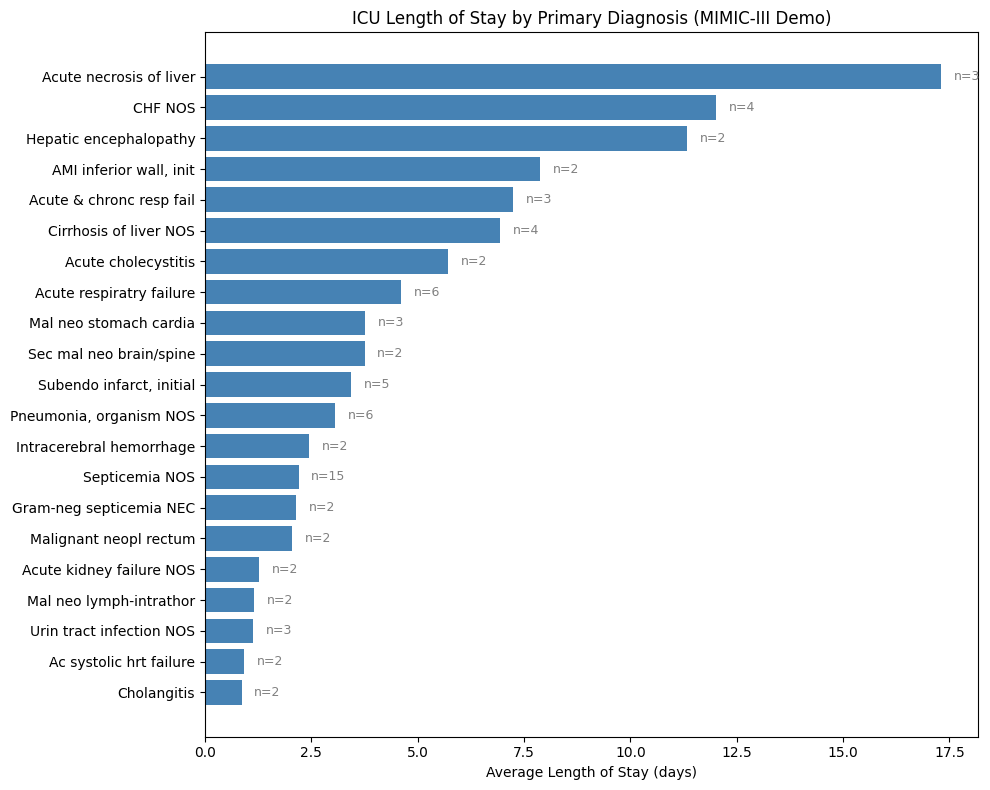

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(los_by_diagnosis['primary_diagnosis'], los_by_diagnosis['avg_los_days'], color='steelblue')

# Annotate each bar with its sample size, so the small-n caveat is visible directly on the chart
for i, (bar, n) in enumerate(zip(bars, los_by_diagnosis['num_admissions'])):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, f'n={n}',
            va='center', fontsize=9, color='gray')

ax.set_xlabel('Average Length of Stay (days)')
ax.set_title('ICU Length of Stay by Primary Diagnosis (MIMIC-III Demo)')
ax.invert_yaxis()  # longest stays at top
plt.tight_layout()
plt.savefig('los_by_diagnosis.png', dpi=150, bbox_inches='tight')
plt.show()

**Pattern:** liver conditions and heart failure cluster at the top with the longest average stays, infections and kidney/urinary issues cluster toward the bottom with shorter ones.

In [13]:
# Secondary angle
# Does insurance type relate to length of stay or care patterns?

# Given insurance type usually has only a handful of categories, each group should have a much larger,
# more trustworthy sample size than individual diagnoses did.

conn = sqlite3.connect('mimic_demo.db')

query = """
SELECT
    a.insurance,
    COUNT(*) AS num_admissions,
    ROUND(AVG(i.los), 2) AS avg_los_days,
    ROUND(MIN(i.los), 2) AS min_los_days,
    ROUND(MAX(i.los), 2) AS max_los_days
FROM admissions a
JOIN icustays i ON a.hadm_id = i.hadm_id
GROUP BY a.insurance
ORDER BY avg_los_days DESC
"""

los_by_insurance = pd.read_sql(query, conn)
print(los_by_insurance)

conn.close()

    insurance  num_admissions  avg_los_days  min_los_days  max_los_days
0    Medicaid               6          8.41          1.26         21.41
1     Private              24          5.89          0.11         35.41
2    Medicare             105          3.93          0.19         31.12
3  Government               1          0.94          0.94          0.94


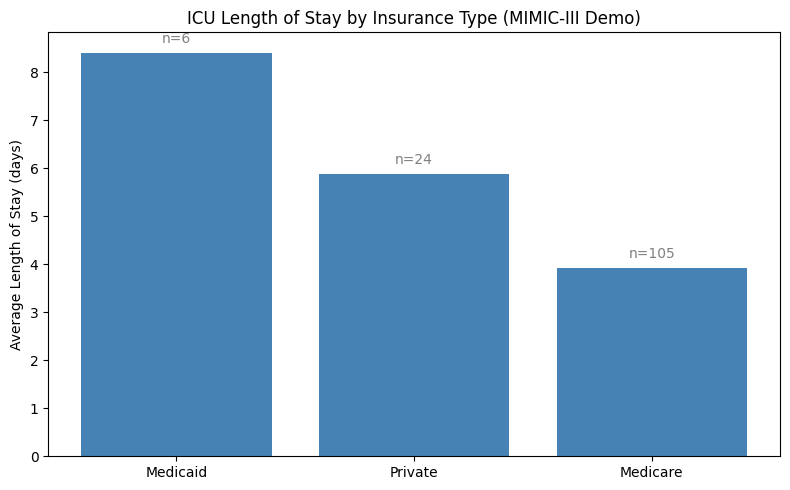

In [15]:
# Government has only 1 admission -- not a meaningful comparison group, exclude from the chart
plot_data = los_by_insurance[los_by_insurance['insurance'] != 'Government']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(plot_data['insurance'], plot_data['avg_los_days'], color='steelblue')

for bar, n in zip(bars, plot_data['num_admissions']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f'n={n}',
            ha='center', fontsize=10, color='gray')

ax.set_ylabel('Average Length of Stay (days)')
ax.set_title('ICU Length of Stay by Insurance Type (MIMIC-III Demo)')
plt.tight_layout()
plt.savefig('los_by_insurance.png', dpi=150, bbox_inches='tight')
plt.show()

### Note: insurance type and confounding

Medicaid admissions show the longest average ICU stay (8.4 days), followed
by Private (5.9) and Medicare (3.9), though Medicaid's sample is small
(n=6) and should be read cautiously alongside the larger Private (n=24)
and Medicare (n=105) groups.

This pattern shouldn't be read as insurance type *causing* longer stays.
Insurance type here likely acts as a proxy for other factors like underlying health status, comorbidity burden, or access to care before admission, rather than a direct driver of length of stay. Medicare's large share of admissions (105/135) also reflects the ICU population skewing older, since Medicare covers patients 65+. A government admission (n=1) was excluded as not meaningful for comparison.

In [21]:
# 3rd prediction: Age at admission

# note: julianday(...) - SQLite's way of converting a date into a single number (days since a reference point),
# which lets me subtract two dates to get an age in days, then convert to years.

conn = sqlite3.connect('mimic_demo.db')

query = """
SELECT
    a.hadm_id,
    p.dob,
    a.admittime,
    i.los,
    CAST((julianday(a.admittime) - julianday(p.dob)) / 365.25 AS INT) AS age_at_admission
FROM admissions a
JOIN patients p ON a.subject_id = p.subject_id
JOIN icustays i ON a.hadm_id = i.hadm_id
"""

age_los = pd.read_sql(query, conn)

# Filter out the anonymization artifact (ages > 100 are not real -- they're
# MIMIC's de-identification shift for patients originally 89+)
age_los_clean = age_los[age_los['age_at_admission'] <= 100].copy()

print(f"Excluded {len(age_los) - len(age_los_clean)} admissions with artifact ages (>100)")
print()
print(age_los_clean[['age_at_admission', 'los']].describe())
print("\nCorrelation between age and LOS (cleaned):", age_los_clean['age_at_admission'].corr(age_los_clean['los']))

conn.close()

Excluded 9 admissions with artifact ages (>100)

       age_at_admission         los
count        127.000000  127.000000
mean          68.984252    4.618736
std           15.848481    6.373267
min           17.000000    0.105900
25%           63.000000    1.261350
50%           72.000000    2.120300
75%           81.000000    4.618500
max           88.000000   35.406500

Correlation between age and LOS (cleaned): -0.2874435300540518


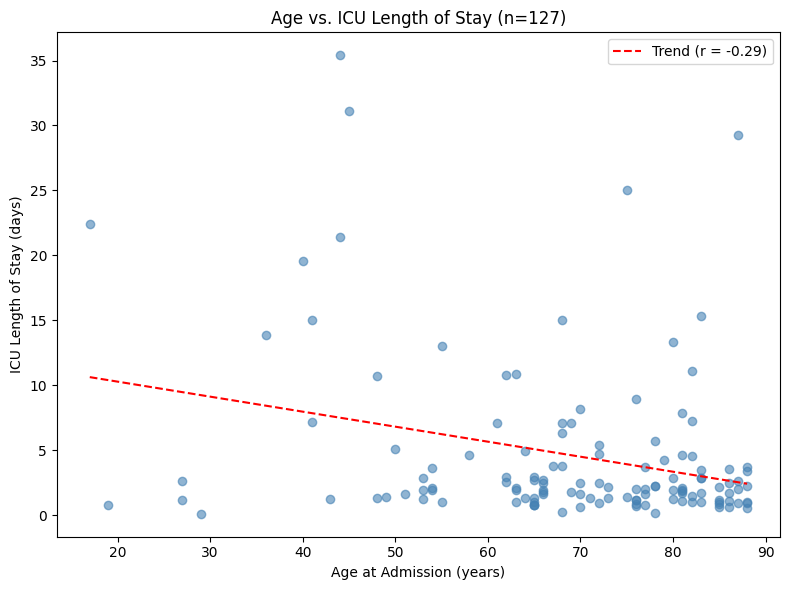

In [22]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(age_los_clean['age_at_admission'], age_los_clean['los'], alpha=0.6, color='steelblue')

# Add a simple trend line to visualize the negative relationship
z = age_los_clean['age_at_admission'].corr(age_los_clean['los'])
import numpy as np
coeffs = np.polyfit(age_los_clean['age_at_admission'], age_los_clean['los'], 1)
trend_x = np.array([age_los_clean['age_at_admission'].min(), age_los_clean['age_at_admission'].max()])
ax.plot(trend_x, coeffs[0]*trend_x + coeffs[1], color='red', linestyle='--', label=f'Trend (r = {z:.2f})')

ax.set_xlabel('Age at Admission (years)')
ax.set_ylabel('ICU Length of Stay (days)')
ax.set_title('Age vs. ICU Length of Stay (n=127)')
ax.legend()
plt.tight_layout()
plt.savefig('age_vs_los.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation: age and length of stay

Across the full cleaned sample (n=127, after excluding 9 admissions with
MIMIC's anonymization age artifacts), age shows a weak negative correlation with ICU length of stay (r = -0.29). Older patients (65+) cluster more consistently toward shorter stays, while younger and middle-aged patients show much greater variability — including most of the dataset's longest outlier stays. Age alone explains only ~8% of the variance in length of stay (r²), meaning it is a weak standalone predictor: most of what determines a given patient's LOS lies elsewhere, in factors like diagnosis severity or complications rather than age itself.

In [25]:
# Pull one clean dataset with all candidate predictors together.
#
# Predictors included:
#   - age_at_admission   : patient age at time of admission (continuous)
#   - num_diagnoses      : count of diagnosis codes for this admission (proxy for illness complexity)
#   - num_procedures     : count of procedures performed during this admission (proxy for treatment intensity)
#   - num_medications    : count of distinct medications prescribed during this admission (proxy for treatment intensity)
#   - admission_type     : EMERGENCY / URGENT / ELECTIVE (categorical)
#   - first_careunit     : which ICU type the patient was first admitted to (categorical)
#
# Outcome:
#   - los                : ICU length of stay, in days

conn = sqlite3.connect('mimic_demo.db')

query = """
SELECT
    a.hadm_id,
    i.los,
    CAST((julianday(a.admittime) - julianday(p.dob)) / 365.25 AS INT) AS age_at_admission,
    a.admission_type,
    i.first_careunit,
    (SELECT COUNT(*) FROM diagnoses_icd d WHERE d.hadm_id = a.hadm_id) AS num_diagnoses,
    (SELECT COUNT(*) FROM procedures_icd pr WHERE pr.hadm_id = a.hadm_id) AS num_procedures,
    (SELECT COUNT(DISTINCT drug) FROM prescriptions rx WHERE rx.hadm_id = a.hadm_id) AS num_medications
FROM admissions a
JOIN patients p ON a.subject_id = p.subject_id
JOIN icustays i ON a.hadm_id = i.hadm_id
"""

full_data = pd.read_sql(query, conn)
conn.close()

# Same artifact-age filter as before -- ages >100 are MIMIC's de-identification
# shift for patients originally 89+, not real values
full_data = full_data[full_data['age_at_admission'] <= 100].copy()

print(full_data.shape)
print(full_data.head())
print("\nCare unit counts:\n", full_data['first_careunit'].value_counts())
print("\nAdmission type counts:\n", full_data['admission_type'].value_counts())
print("\nNew predictor summaries:\n", full_data[['num_procedures', 'num_medications']].describe())

(127, 8)
   hadm_id      los  age_at_admission admission_type first_careunit  \
0   142345   1.6325                70      EMERGENCY           MICU   
1   105331  13.8507                36      EMERGENCY           MICU   
2   165520   2.6499                87      EMERGENCY           MICU   
3   199207   2.1436                73      EMERGENCY            CCU   
4   177759   1.2938                48      EMERGENCY           MICU   

   num_diagnoses  num_procedures  num_medications  
0             21               7               34  
1              6               2                0  
2              9               1               20  
3             14               2               52  
4             14               4               32  

Care unit counts:
 first_careunit
MICU     71
SICU     22
CCU      18
TSICU    10
CSRU      6
Name: count, dtype: int64

Admission type counts:
 admission_type
EMERGENCY    117
ELECTIVE       8
URGENT         2
Name: count, dtype: int64

New predictor

In [26]:
import statsmodels.api as sm
import pandas as pd

# Final regression: age, illness complexity (diagnoses), and treatment intensity
# (procedures, medications), plus care unit and admission type as categorical controls.

# Convert categorical variables into numeric "dummy" columns the regression can use
# (drop_first=True avoids redundancy -- one category becomes the "baseline" others are compared against)
model_data = pd.get_dummies(full_data, columns=['first_careunit', 'admission_type'], drop_first=True)

# Define predictors (X) and outcome (y)
predictor_cols = [c for c in model_data.columns if c not in ['hadm_id', 'los']]
X = model_data[predictor_cols].astype(float)
y = model_data['los']

X = sm.add_constant(X) # adds an intercept term, standard practice for regression

model_final = sm.OLS(y, X).fit()
print(model_final.summary())

                            OLS Regression Results                            
Dep. Variable:                    los   R-squared:                       0.540
Model:                            OLS   Adj. R-squared:                  0.501
Method:                 Least Squares   F-statistic:                     13.63
Date:                Mon, 14 Sep 2026   Prob (F-statistic):           1.34e-15
Time:                        16:25:03   Log-Likelihood:                -365.58
No. Observations:                 127   AIC:                             753.2
Df Residuals:                     116   BIC:                             784.4
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

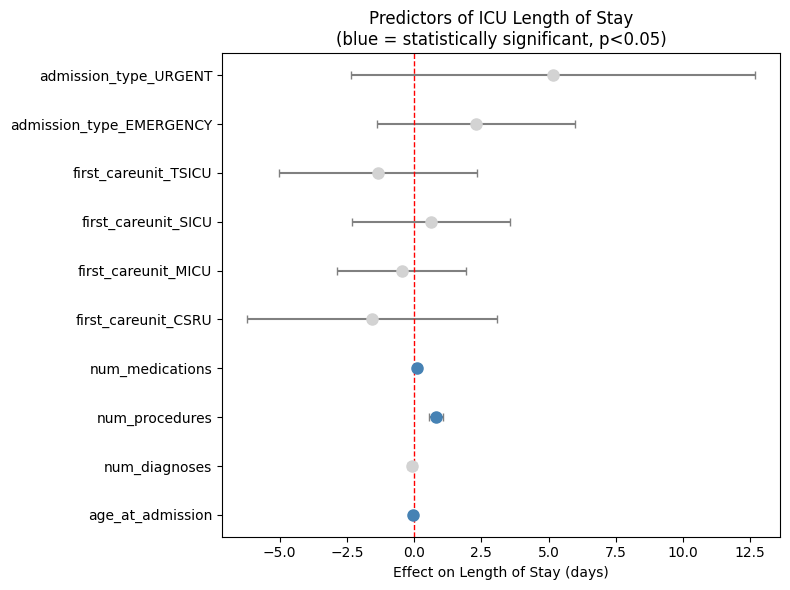

In [27]:
import matplotlib.pyplot as plt

# Pull coefficients, confidence intervals, and p-values from the final model
coefs = model_final.params.drop('const')
conf_int = model_final.conf_int().drop('const')
pvalues = model_final.pvalues.drop('const')

fig, ax = plt.subplots(figsize=(8, 6))

colors = ['steelblue' if p < 0.05 else 'lightgray' for p in pvalues]
y_pos = range(len(coefs))

ax.errorbar(coefs, y_pos,
            xerr=[coefs - conf_int[0], conf_int[1] - coefs],
            fmt='o', color='black', ecolor='gray', capsize=3)

for i, c in enumerate(colors):
    ax.plot(coefs.iloc[i], i, 'o', color=c, markersize=8, zorder=3)

ax.axvline(x=0, color='red', linestyle='--', linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(coefs.index)
ax.set_xlabel('Effect on Length of Stay (days)')
ax.set_title('Predictors of ICU Length of Stay\n(blue = statistically significant, p<0.05)')
plt.tight_layout()
plt.savefig('los_regression_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation: what predicts ICU length of stay

A multiple regression combining age, illness complexity (number of
diagnoses), treatment intensity (number of procedures and distinct
medications), care unit, and admission type explains a substantial share
of the variation in ICU length of stay (R² = 0.54, p < 0.001).

**Number of procedures (p<0.001) and number of medications (p=0.001) are
the strongest predictors** — patients who underwent more procedures and
received more distinct medications had meaningfully longer stays. Age was
also a significant, though weaker, predictor (p=0.041): older patients
tended to have slightly shorter stays. Number of diagnoses, care unit, and admission type did not show statistically reliable independent effects.

The coefficient plot above makes this visible directly: num_procedures
stands out with a tight, confident interval clearly separated from zero,
while age and num_medications are significant but comparatively modest
and less precisely estimated — visible in their smaller distance from the
zero line relative to their error bars.

**Conclusion:** treatment intensity — how much a patient is actively being treated, rather than how many conditions they're diagnosed with or which unit they're in — is the strongest signal of ICU length of stay in this dataset. This makes clinical sense: procedures and medications reflect real-time treatment complexity directly, whereas diagnosis count or care unit are more indirect proxies for how sick or resource-intensive a patient's care actually is.